# Detecting Misinformation with AI
### INFO 629 — Final Project Report
**Name:** Rajat Sharma  
**Date:** 9th June 2026

## 1. Why

A landmark 2018 MIT study ([Vosoughi et al., *Science*](https://www.science.org/doi/10.1126/science.aap9559)) found that false news spreads **six times faster** on social media than true news, and reaches a substantially larger audience before any correction is issued. By the time a fact-check is published, the original story may have already reached millions of people. The 2016 US election cycle, the COVID-19 pandemic, and subsequent geopolitical events demonstrated that large-scale disinformation can affect public health decisions, financial markets, and democratic processes.

Human fact-checkers cannot operate at the speed and volume required. With the scale of content being posted, automated detection is therefore a necessary as a first line of defence.

### Project Goals

This project addresses two research questions:

**Performance:** How accurately do classical machine learning, deep learning, and transformer models classify fake news across multiple benchmark datasets?

**Generalisation:** Do models trained on one dataset or domain generalize to unseen sources, different publication styles, and different text lengths? What is the primary barrier to cross-domain transfer?

### Expected Impact

A model that genuinely learns linguistic markers of misinformation — rather than memorizing outlet-specific writing styles, could serve as a scalable pre-screening tool that routes suspicious content to human reviewers. Understanding *why* existing models fail at cross-domain transfer is equally valuable, it provides concrete guidance on dataset construction and training strategy for the next generation of detection systems.

---
## 2. What

### Domain

The task for this model is text classification: given the headline and body of a news article (or a short claim/tweet), predict whether the content is reliable or misleading. The project intentionally spans multiple sub-tasks — binary article classification, six-class political claim veracity, and tweet-level rumour verification, to test generalization.

### 2.2 Datasets

Five datasets were used, each serving a distinct purpose.

| Dataset | Size | Label type | Primary use | Link |
|---|---|---|---|---|
| ISOT | 39,076 articles | Binary (fake / real) | Main training benchmark | https://onlineacademiccommunity.uvic.ca/isot/2022/11/27/fake-news-detection-datasets/ |
| WELFake | 63,644 articles | Binary (fake / real) | Cross-source training benchmark | https://zenodo.org/records/4561253 |
| LIAR | 12,791 claims | 6-class veracity | Political fact-checking sub-task | https://aclanthology.org/P17-2067/ |
| NELA-GT (sampled) | 500,000 articles | 3-class (Reliable / Questionable / Conspiracy) | Source-diversity training | https://github.com/MELALab/nela-gt |
| PHEMEplus | 1,401 rumour threads | Binary (false / true rumour) | Out-of-domain (tweet) evaluation | https://aclanthology.org/2022.fever-1.6/ |

#### ISOT
~39,000 English news articles scraped between 2016 and 2017. Real articles are **exclusively from Reuters**; fake articles are from a curated list of unreliable websites flagged by PolitiFact and Wikipedia. The dataset is widely used in the literature and serves as a clean, high-signal benchmark. The single-source structure of the real class is a known limitation addressed later in this report.

**Split (80/10/10 stratified):** 31,260 train / 3,908 val / 3,908 test
**Label balance (train):** Fake = 14,320 (46%) / Real = 16,940 (54%)

#### WELFake
~64,000 articles assembled from four existing datasets: Kaggle Fake News, McIntire, Reuters, and BuzzFeed Political. The multi-source composition produces more varied writing styles than ISOT, although Reuters articles are still the dominant real-news source.

**Split (80/10/10 stratified):** 50,915 train / 6,364 val / 6,365 test  
**Label balance (train):** Fake = 27,814 (55%) / Real = 23,101 (45%)

#### LIAR
12,791 short political statements from PolitiFact, each annotated with one of six veracity labels: *pants-on-fire, false, barely-true, half-true, mostly-true, true*.The dataset also includes rich metadata: speaker identity, party affiliation, subject tags, state, and the speaker's historical truthfulness record across prior PolitiFact rulings. Published state-of-the-art (text-only) is approximately 30% macro-F1, reflecting the genuine difficulty of distinguishing six fine-grained veracity levels from short text alone.

**Split (canonical):** 10,240 train / 1,284 val / 1,267 test  
**Label balance (train):** Roughly uniform across 6 classes (839–2,114 per class)

#### NELA-GT (Sampled 500k)
NELA-GT is a multi-year corpus of ~4.2 million articles from 488 publishers, annotated at the **publisher level** using Media Bias / Fact Check (MBFC) ratings. Publisher ratings are mapped to three classes: Reliable (MBFC categories: Left, Left-Center, Least Biased, Right-Center, Right, Pro-Science), Questionable (MBFC: Questionable Source), and Conspiracy (MBFC: Conspiracy-Pseudoscience). Satire-rated publishers are excluded because satire is a distinct genre rather than misinformation.

A stratified subsample of 500,000 articles was drawn across all 457 publishers with usable MBFC labels to avoid running into memory issue with the compute resources available.

**Split (80/10/10 stratified):** 399,938 train / 50,018 val / 50,044 test  
**Label balance (train):** Reliable = 289,512 (72%) / Questionable = 76,780 (19%) / Conspiracy = 33,646 (8%)  
**The class imbalance reflects the real-world MBFC publisher landscape** — the majority of publishers are rated as reliable.

#### PHEMEplus
1,401 verified rumour threads from five breaking-news Twitter events: Each thread consists of a source tweet and its reply tree; only the source tweet text is used for classification. Labels are derived from post-hoc crowd annotation: *true rumour* → 1 (Real), *false rumour* → 0 (Fake). Unverified threads are excluded. PHEMEplus is used exclusively as an **out-of-domain evaluation** target, no model is trained on it.

**Total:** 1,401 threads (fake = 393 / real = 1,008)  
**Key domain gap:** Tweet-length text (~15–25 words) vs. article-length text (~300–1,000 words).

### Classification ML Model Variants

Three tiers of classification technique were evaluated:

1. **Classical ML** — TF-IDF feature extraction with Logistic Regression, LinearSVC, Random Forest, and XGBoost.
2. **Deep Learning** — GloVe pre-trained word embeddings with BiLSTM and TextCNN architectures.
3. **Transformers** — Fine-tuned BERT-base-uncased and RoBERTa-base.

In addition, SHAP (SHapley Additive exPlanations) was used for model interpretability on TF-IDF classifiers.

---
## 3. Who

### Primary Stakeholders

| Stakeholder | Need | How this project addresses it |
|---|---|---|
| Social media platforms | Pre-screen flagged content before human review | Classical and DL models offer sub-millisecond to 20ms inference; suitable for real-time pipelines |
| Newsroom fact-checkers | Prioritize which stories warrant investigation | Ranking articles by predicted unreliability score reduces manual triage |
| Researchers and educators | Understand model limitations and failure modes | Cross-dataset probes and SHAP analysis surface the source-fingerprinting problem transparently |

### Use Cases

**Content moderation pipeline:** A platform API scores incoming articles in real time. Articles above a threshold are flagged for human review rather than immediately removed, preserving editorial judgement.

**Browser extension:** A lightweight LR or TextCNN model (0.44–0.76 ms inference) could run client-side or via an API to annotate news links as a user browses.

---
## 4. How

### Preprocessing Pipeline

All datasets share a common cleaning pipeline.

In [1]:
# Preprocessing — representative snippet from src/utils/data_loader.py
import re, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Shared cleaning step applied to all datasets."""
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    return ' '.join(tokens)

def make_text_column(df, title_col='title', body_col='text'):
    """Concatenate headline + body into a single 'text' field."""
    return df[title_col].fillna('') + ' ' + df[body_col].fillna('')

**Steps applied to every dataset:**
1. **Text extraction** — headline and article body concatenated into a single text field.
2. **Cleaning** — HTML tags, URLs stripped; lowercased; tokenised with NLTK; stopwords removed.
3. **Label encoding** — dataset-specific.
4. **Stratified splits** — 80% train / 10% validation / 10% test, stratified by label.
5. **Tier-specific feature extraction** — TF-IDF for classical models; GloVe token IDs for DL; AutoTokenizer for transformers.

### Label Encoding

| Dataset | Labels | Encoding |
|---|---|---|
| ISOT / WELFake | Fake / Real | 0 = Fake, 1 = Real |
| LIAR | pants-on-fire, false, barely-true, half-true, mostly-true, true | 0–5 (ordinal) |
| NELA-GT | Reliable, Questionable, Conspiracy | 0, 1, 2 |
| PHEMEplus | false rumour, true rumour | 0, 1 |

For **NELA cross-dataset evaluation** against binary targets (ISOT, WELFake, PHEMEplus), a binary collapse is applied: Reliable (0) → Real (1); Questionable (1) + Conspiracy (2) → Fake (0). Probabilities are collapsed as P(Fake) = P(class=1) + P(class=2).

### Classical Models — Feature Engineering

TF-IDF was chosen because it is interpretable (features are vocabulary tokens), fast at inference, and provides a strong baseline that reveals dataset-specific artefacts.

In [2]:
# TF-IDF setup — from src/classical/features.py
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50_000,    # top 50k tokens by corpus frequency
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # log-normalise term frequencies
    min_df=3,               # ignore very rare terms
    strip_accents='unicode',
    analyzer='word',
    stop_words=None,        # stopwords already removed in cleaning
)

**Model-specific decisions:**

- **Logistic Regression:** L2 regularisation, max_iter=1000, C=1.0. Chosen as the primary interpretable baseline LR models are fast, and compatible with LinearExplainer for SHAP.
- **LinearSVC:** Hinge loss, C=0.1. Faster than kernel SVC at scale.
- **Random Forest:** n_estimators=100, max_features='sqrt', n_jobs=4. The max_features='sqrt' setting is critical — without it, each split evaluates all 50,000 TF-IDF features, causing OOM on large datasets. For NELA (400k rows), further reduced to n_estimators=50, max_samples=0.5 to fit in RAM.
- **XGBoost:** n_estimators=200, max_depth=6, learning_rate=0.1, tree method hist for sparse input efficiency.

### Deep Learning Models

GloVe 840B-token, 300-dimensional pre-trained embeddings were used. The vocabulary was built from the training corpus (top 30,000 tokens by frequency) with a coverage of 95.1% on the NELA-sampled set.

In [3]:
# BiLSTM architecture — from src/deep_learning/models.py
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, embedding_matrix, num_classes=2, hidden=256, layers=2, dropout=0.3):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hn, _) = self.lstm(emb)
        # concatenate last hidden state from both directions
        out = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(out))

In [4]:
# TextCNN architecture — from src/deep_learning/models.py
class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, num_classes=2, num_filters=128, filter_sizes=(2,3,4,5)):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)  # (B, D, L)
        pooled = [F.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        out = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(out))

**Training configuration (DL):**
- Optimiser: Adam, lr=1e-3, weight decay 1e-5
- Batch size: 64 (ISOT/WELFake), 128 (NELA)
- Early stopping: patience=3 epochs on validation macro-F1
- Max sequence length: 512 tokens (truncated or padded)
- Hardware: Local RTX 4080 Super (ISOT/WELFake); Google Colab A100 (NELA 500k)

**Frozen vs. finetuned:** In the *frozen* variant, the embedding layer weights are held fixed and only the classification head is trained. In the *finetuned* variant, all weights (including embeddings) are updated. Finetuned consistently outperforms frozen by 0.0–0.003 F1 on binary datasets, confirming that domain adaptation in the embedding space provides marginal gains when GloVe coverage is already high.

### Transformer Models

In [5]:
# Transformer classifier — from src/transformers_/models.py
from transformers import AutoModel
import torch.nn as nn

class TransformerClassifier(nn.Module):
    def __init__(self, model_name: str, num_classes: int = 2, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size  # 768 for base models
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.classifier(self.dropout(pooled))

**Training configuration (Transformers):**
- Optimiser: AdamW, lr=2e-5
- Batch size: 32, gradient accumulation × 2
- Max sequence length: 512 tokens (HuggingFace AutoTokenizer)
- Early stopping: patience=2 on validation macro-F1
- Hardware: RTX 4080 Super

Models: bert-base-uncased (110M params) and roberta-base (125M params). Both evaluated in frozen (encoder fixed, head only) and finetuned variants.

### Evaluation Protocol

Three evaluation types were used:

1. **Within-dataset:** Train and test on the same dataset's splits. Standard held-out test set.
2. **Cross-dataset probe:** Train on dataset A, evaluate on dataset B's test set without any fine-tuning on B. Measures genuine domain transfer.
3. **Out-of-domain (OOD):** Evaluate on PHEMEplus — a completely different modality (tweets), never seen during training.

**Primary metrics:** Macro-F1 (equal weight per class; robust to imbalance), ROC-AUC.  
**Secondary metrics:** Accuracy, per-class precision/recall/F1, inference latency (ms/sample, CPU, single-sample batch).

---
## 5. How Good

### Evaluation Metrics

**Macro-F1** is the primary metric throughout. It is the unweighted mean of per-class F1 scores, making it robust to class imbalance. For binary tasks, Macro-F1 = (F1_fake + F1_real) / 2. For the 3-class NELA task and 6-class LIAR task, it equally weights all classes. For NELA specifically, a Macro-F1 of 0.33 corresponds to random chance (three equally likely classes); the equivalent LIAR baseline is 0.167.

**ROC-AUC** is the secondary metric. For binary tasks, this is the standard one-vs-rest AUC. For the 3-class NELA task, it is computed as the macro-averaged OVR AUC across all three classes.

**Inference latency** (ms per sample) is measured on CPU, single-sample batches, over 100 samples, to simulate a real-time scoring endpoint.

### Within-Dataset Results

#### ISOT

| Model | Tier | Macro-F1 | ROC-AUC | Latency (ms) |
|---|---|---|---|---|
| LR | Classical | 0.9943 | 0.9999 | 0.44 |
| LinearSVC | Classical | 0.9969 | 1.0000 | 2.41 |
| Random Forest | Classical | 0.9961 | 0.9995 | 45.50 |
| XGBoost | Classical | 0.9974 | 0.9999 | 2.83 |
| BiLSTM (finetuned) | Deep Learning | 0.9987 | 0.9997 | 22.28 |
| BiLSTM (frozen) | Deep Learning | 0.9985 | 0.9998 | 21.16 |
| TextCNN (finetuned) | Deep Learning | 0.9985 | 0.9997 | 0.76 |
| TextCNN (frozen) | Deep Learning | 0.9987 | 1.0000 | 0.91 |
| BERT (finetuned) | Transformer | 0.9990 | 1.0000 | 7.35 |
| BERT (frozen) | Transformer | 0.8425 | 0.9401 | 8.22 |
| **RoBERTa (finetuned)** | Transformer | **0.9997** | **1.0000** | 7.54 |

**Key observation:** Every finetuned model exceeds 99.4% Macro-F1 on ISOT. The spread between the best classical model (XGBoost, 0.9974) and the best transformer (RoBERTa, 0.9997) is only **0.0023** — statistically negligible and practically irrelevant. Performance saturation at this level suggests the task is near-trivially solvable given the dataset structure. The *reason* is examined in Section 5.5 (SHAP analysis).

BERT (frozen) at 0.8425 is the only notable underperformer — frozen BERT with a randomly-initialised classification head struggles until the head adapts, but without encoder fine-tuning the representations are not task-specific.

#### WELFake

| Model | Tier | Macro-F1 | ROC-AUC | Latency (ms) |
|---|---|---|---|---|
| LR | Classical | 0.9737 | 0.9965 | 0.52 |
| LinearSVC | Classical | 0.9762 | 0.9969 | 2.44 |
| Random Forest | Classical | 0.9630 | 0.9937 | 64.07 |
| XGBoost | Classical | 0.9714 | 0.9968 | 0.94 |
| BiLSTM (finetuned) | Deep Learning | 0.9854 | 0.9986 | 20.27 |
| BiLSTM (frozen) | Deep Learning | 0.9878 | 0.9990 | 20.19 |
| TextCNN (finetuned) | Deep Learning | 0.9867 | 0.9990 | 0.79 |
| TextCNN (frozen) | Deep Learning | 0.9829 | 0.9985 | 0.97 |
| BERT (finetuned) | Transformer | 0.9911 | **0.9995** | 7.54 |
| **RoBERTa (finetuned)** | Transformer | **0.9951** | 0.9991 | 7.32 |

WELFake is slightly harder for classical models (RF drops to 0.963 vs 0.996 on ISOT), but deep learning and transformers close the gap almost completely. The multi-source composition of WELFake produces more varied vocabulary, slightly diluting the source-identity signal that classical models exploit.

#### NELA-GT (3-class)

| Model | Tier | Macro-F1 | ROC-AUC (OVR) | PHEMEplus F1 (cross-eval) |
|---|---|---|---|---|
| LR | Classical | 0.7179 | 0.9170 | 0.5029 |
| LinearSVC | Classical | 0.7095 | 0.9105 | 0.4959 |
| Random Forest* | Classical | 0.5086 | 0.8541 | 0.4184 |
| XGBoost | Classical | 0.6837 | 0.9054 | 0.4184 |
| **BiLSTM (finetuned)** | Deep Learning | **0.7458** | **0.9295** | 0.5068 |
| TextCNN (finetuned) | Deep Learning | 0.7241 | 0.9140 | 0.4898 |

\* RF: n_estimators=50, max_samples=0.5 due to dataset scale (400k rows × 50k features).
Transformers not evaluated on NELA due to compute constraints.

**Key observations:**
- NELA is the only dataset where tier differences are meaningful. BiLSTM (0.7458) outperforms LR (0.7179) by a margin that matters in practice.
- RF collapses to 0.5086 — barely above random chance (0.33) for 3 classes. At 400,000 training rows and 50,000 TF-IDF features, ensemble trees cannot efficiently partition the high-dimensional sparse space even with max_features='sqrt'.
- The 3-class ROC-AUC spread (0.854–0.930) is the most honest measure of model quality across the entire study.
- BiLSTM's best PHEMEplus cross-eval score (0.5068) confirms that sequence-level representations learned on 500k articles partially transfer to tweet-length text and potentialy should improve further when trained on complete list of articles in NELA-GT.

#### LIAR (6-class political claims)

| Model | Tier | Text-only Macro-F1 | With Metadata F1 (Classical) | Random baseline |
|---|---|---|---|---|
| LR | Classical | 0.2134 | 0.4428 | 0.167 |
| LinearSVC | Classical | 0.2052 | 0.3676 | 0.167 |
| Random Forest | Classical | 0.2240 | 0.4190 | 0.167 |
| XGBoost | Classical | 0.2342 | 0.4181 | 0.167 |
| BiLSTM | Deep Learning | 0.2449 | — | 0.167 |
| TextCNN | Deep Learning | 0.2417 | — | 0.167 |
| BERT | Transformer | 0.2722 | — | 0.167 |
| RoBERTa | Transformer | 0.2740 | — | 0.167 |

**Key observations:**
- No model substantially outperforms the 0.167 random baseline on text alone. Even RoBERTa at 0.274 is only 0.107 above chance, although is close to the published text-only SOTA of ~0.30.
- Adding available metadata (speaker party, credit history, subject tags) to LR raises the score from 0.213 to **0.443**.


**Conclusion:** 
- For political fact-checking, *who says something* is more predictive than *what they say*. Metadata encodes institutional credibility that text does not.
- LIAR is a fundamentally different task from article-level fake news detection and should not be conflated with it in benchmarks.

### Cross-Dataset Generalisation

| Model | Tier | ISOT→WELFake F1 | WELFake→ISOT F1 | Combined→WELFake F1 | NELA→ISOT F1 | NELA→PHEMEplus F1 |
|---|---|---|---|---|---|---|
| LR | Classical | 0.2612 | 0.0041 | 0.3844 | 0.5709 | 0.5029 |
| LinearSVC | Classical | 0.2655 | 0.0026 | 0.3852 | 0.5474 | 0.4959 |
| Random Forest | Classical | 0.3128 | 0.0026 | 0.3826 | 0.3691 | 0.4184 |
| XGBoost | Classical | 0.3078 | 0.0018 | 0.3851 | 0.5021 | 0.4184 |
| BiLSTM (finetuned) | Deep Learning | 0.3103 | 0.0003 | 0.3866 | 0.5615 | 0.5068 |
| BiLSTM (frozen) | Deep Learning | 0.3064 | 0.0000 | 0.3850 | — | — |
| TextCNN (finetuned) | Deep Learning | 0.3162 | 0.0008 | 0.3855 | 0.5594 | 0.4898 |
| TextCNN (frozen) | Deep Learning | 0.3163 | 0.0005 | 0.3853 | — | — |
| BERT (finetuned) | Transformer | 0.2358 | — | 0.3884 | — | — |
| BERT (frozen) | Transformer | 0.3076 | — | — | — | — |
| RoBERTa (finetuned) | Transformer | 0.1944 | — | 0.3848 | — | — |
| RoBERTa (frozen) | Transformer | 0.3072 | — | — | — | — |

**Finding 1 — ISOT→WELFake collapse (0.19–0.31):**  
Every model trained on ISOT scores near-random on WELFake. This shows that models have learned to identify Reuters writing style as the signal for "real," not linguistic characteristics of real atricles.

**Finding 2 — WELFake→ISOT complete failure (0.000–0.004):**  
Models trained on WELFake predict a single class for all ISOT articles. The labels are incompatible: WELFake's "real" class contains multiple source styles, but ISOT's "real" is exclusively Reuters. The WELFake-trained model finds no basis for distinguishing ISOT's two classes.

**Finding 3 — Combined→WELFake at ~0.385:**
Even training on a merged ISOT+WELFake corpus does better, but is still not better than random.

**Finding 4 — NELA→ISOT lift (0.37–0.57):**  
Models trained on NELA-GT (457 sources) score 0.50–0.57 on ISOT cross-eval. LR improves from 0.26 (ISOT-trained, cross-eval) to **0.57** (NELA-trained). Source diversity is the mechanism: when the training data includes hundreds of reliable and unreliable publishers, the model cannot rely on a single outlet's fingerprint. This should potentially improve further with training on the complete articles list from the NELA-GT dataset.

**Finding 5 — NELA→PHEMEplus (0.42–0.51):**  
NELA-trained models score 0.50–0.51 on PHEMEplus tweets — nearly double the 0.27 scored by ISOT-trained models, despite no tweet exposure during training. This is the best cross-domain result in the study and confirms that source diversity improves generalization even across modality boundaries.

### Combined Dataset Results

| Model | Tier | Combined F1 | Combined→WELFake F1 | PHEMEplus OOD F1 |
|---|---|---|---|---|
| LR | Classical | 0.9638 | 0.3844 | 0.5059 |
| LinearSVC | Classical | 0.9656 | 0.3852 | 0.4870 |
| Random Forest | Classical | 0.9508 | 0.3826 | 0.4116 |
| XGBoost | Classical | 0.9681 | 0.3851 | 0.4259 |
| BiLSTM (finetuned) | Deep Learning | 0.9813 | 0.3866 | 0.4259 |
| BiLSTM (frozen) | Deep Learning | 0.9841 | 0.3850 | 0.4332 |
| TextCNN (finetuned) | Deep Learning | 0.9780 | 0.3855 | 0.4145 |
| TextCNN (frozen) | Deep Learning | 0.9793 | 0.3853 | 0.4214 |
| **BERT (finetuned)** | Transformer | **0.9903** | 0.3884 | 0.4336 |
| RoBERTa (finetuned) | Transformer | 0.9887 | 0.3848 | 0.3759 |

The Combined dataset hurts the within dataset F1 by ~0.3–2% compared to training on ISOT alone (a model trained on more diverse data learns a slightly harder task), but PHEMEplus OOD performance improves meaningfully. LR on Combined scores 0.506 vs 0.305 for LR on ISOT. This finding builds into the results we saw from models trained on NELA-GT, that training on multiple publishers helps the model generalize better.


### SHAP Interpretability Analysis

SHAP LinearExplainer was applied to LR models and TreeExplainer to XGBoost. All SHAP analyses use 500 randomly sampled test examples.

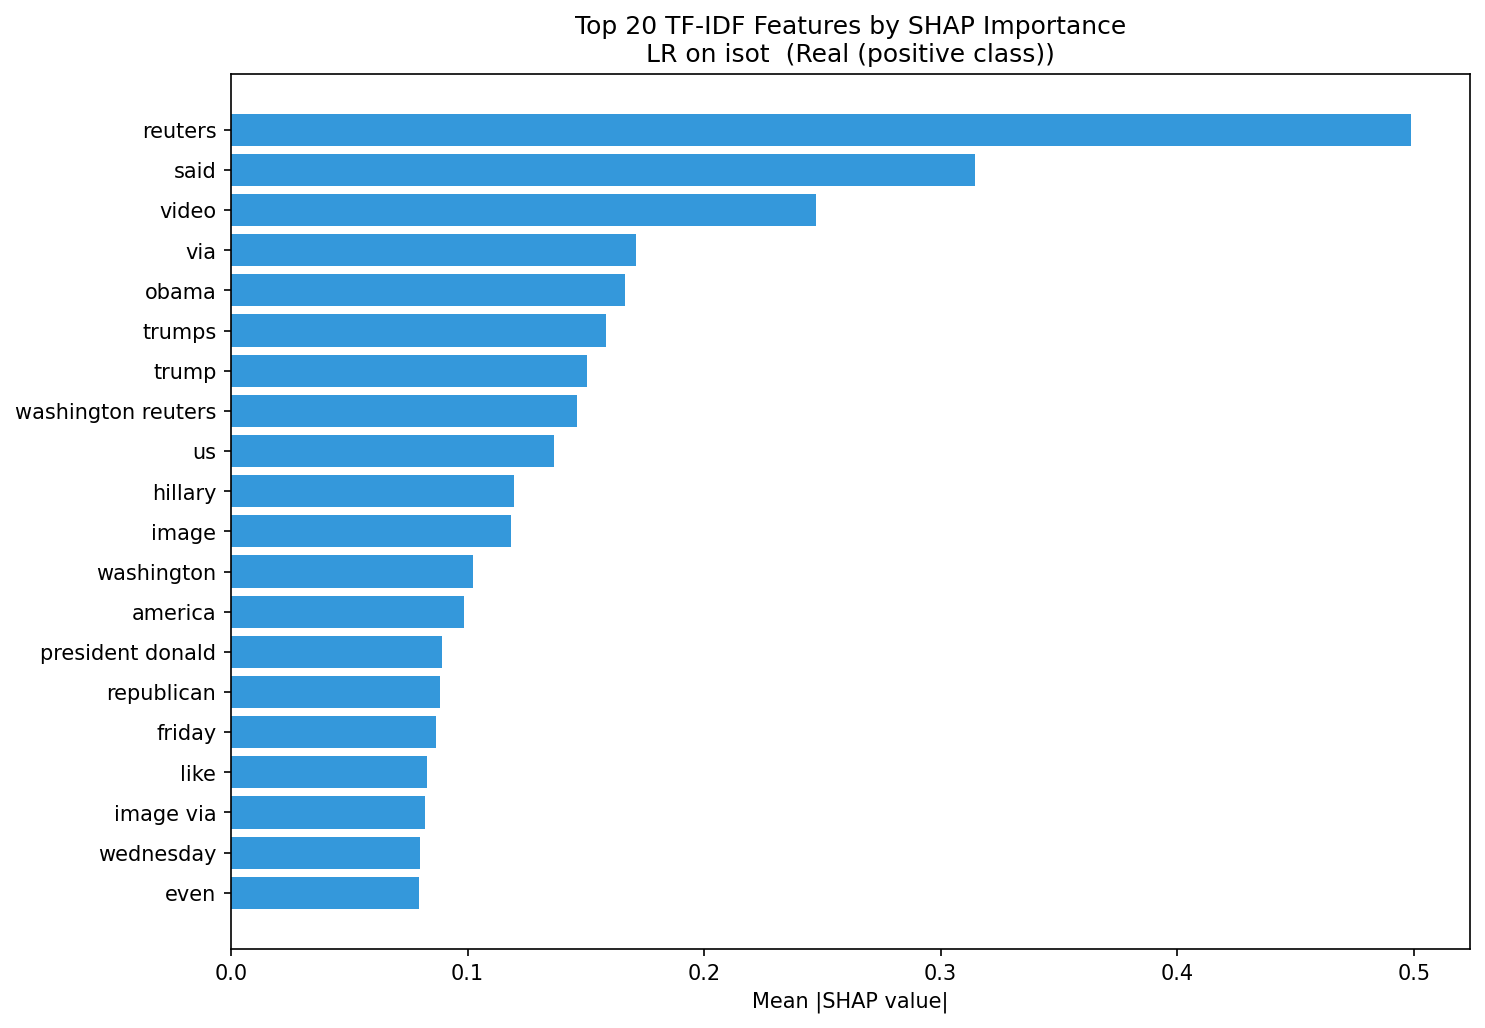

In [6]:
from IPython.display import Image, display
import os

shap_results = '../results/shap'
display(Image(os.path.join(shap_results, 'isot_lr', 'global_importance_top20.png'), width=700))

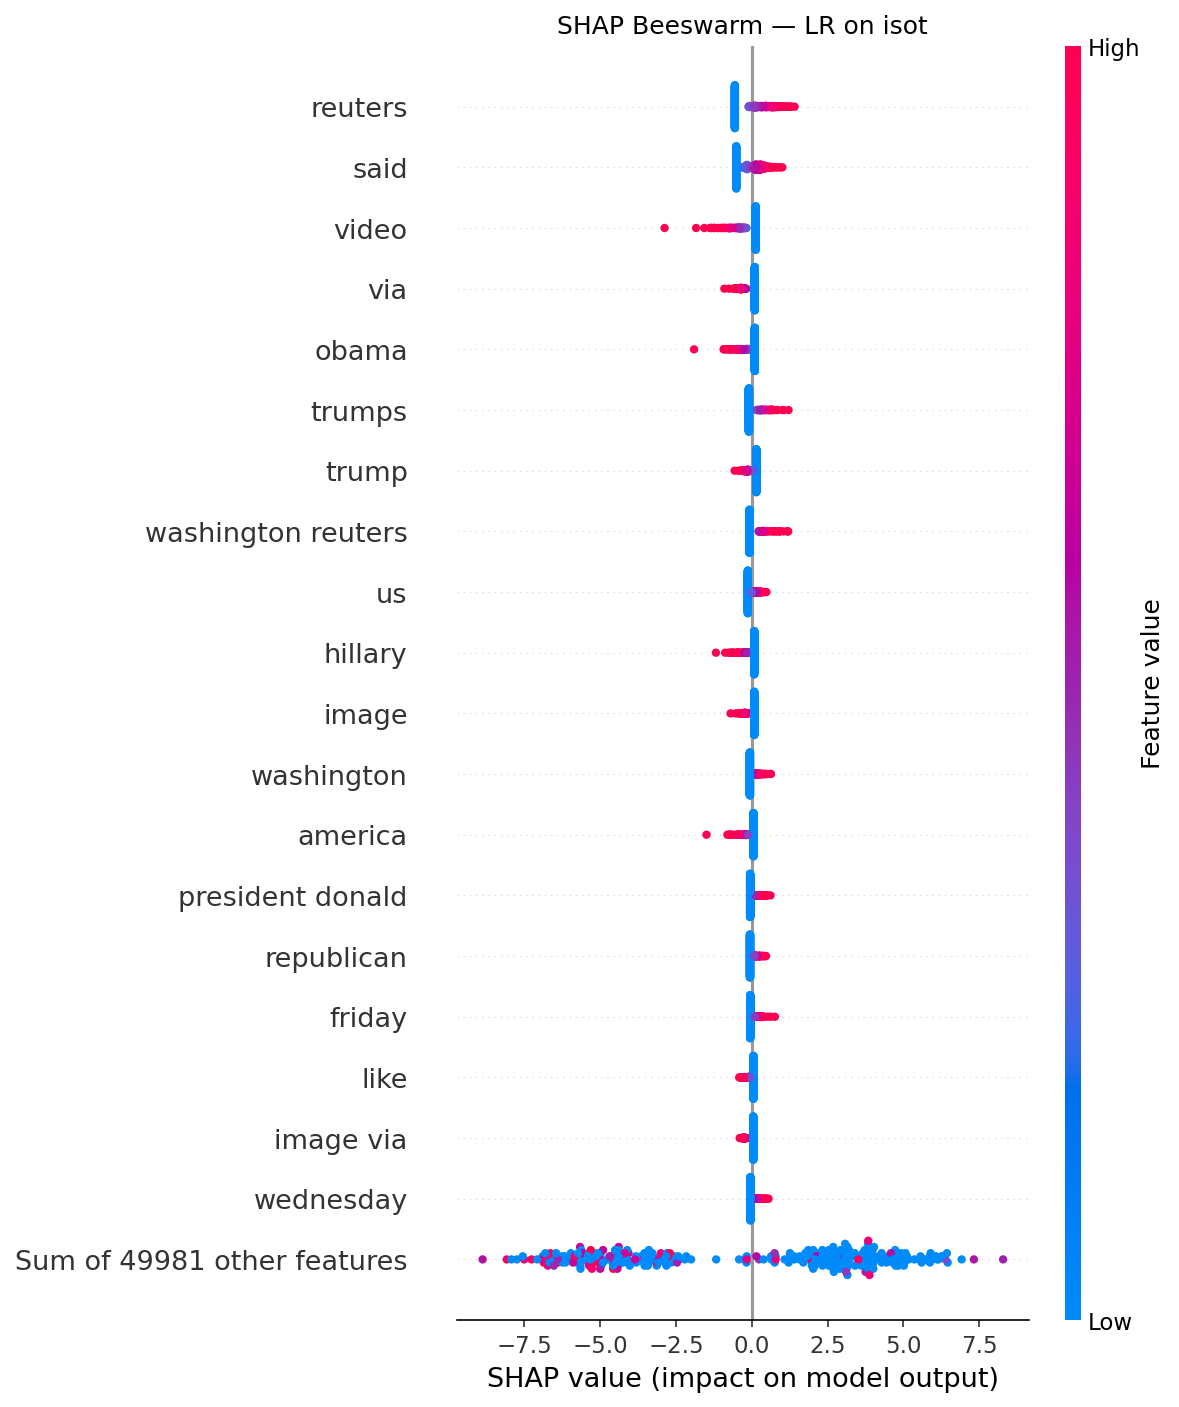

In [7]:

display(Image(os.path.join(shap_results, 'isot_lr', 'beeswarm.png'), width=700))

**ISOT SHAP finding:** **"reuters"** is the single highest-importance feature, with approximately twice the mean |SHAP value| of the next-highest feature. This confirms our earlier observation that the model has learned a single rule: *does this article mention Reuters?* If yes, it is real; if no, it is more likely fake.

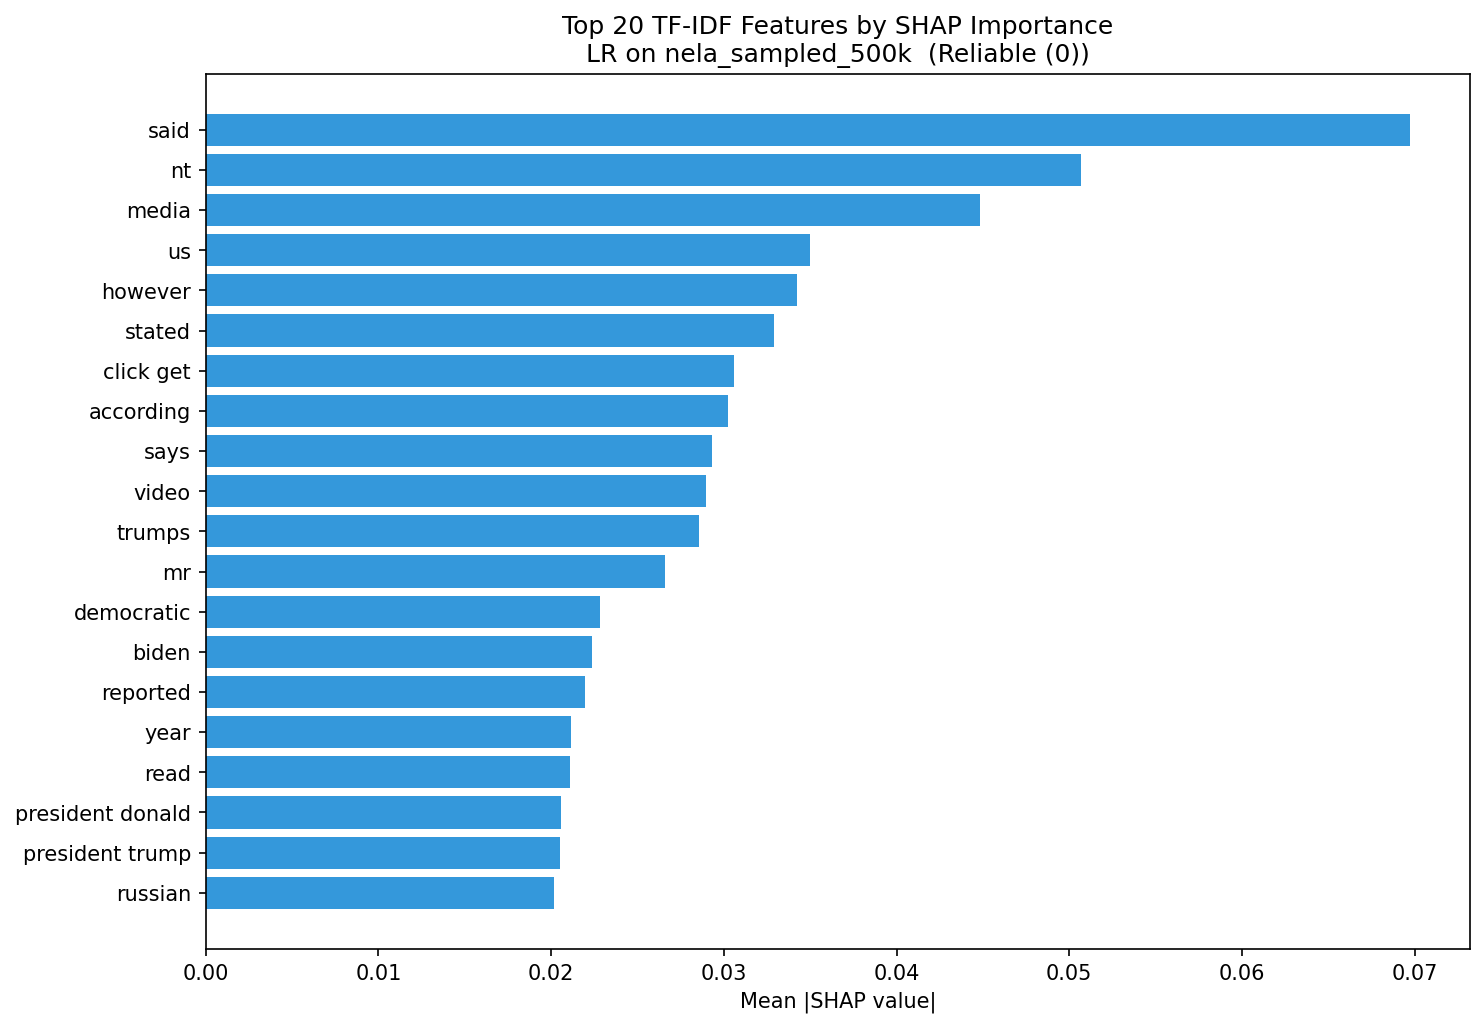

In [9]:
display(Image(os.path.join(shap_results, 'nela_sampled_500k_lr', 'global_importance_top20_cls0.png'), width=700))

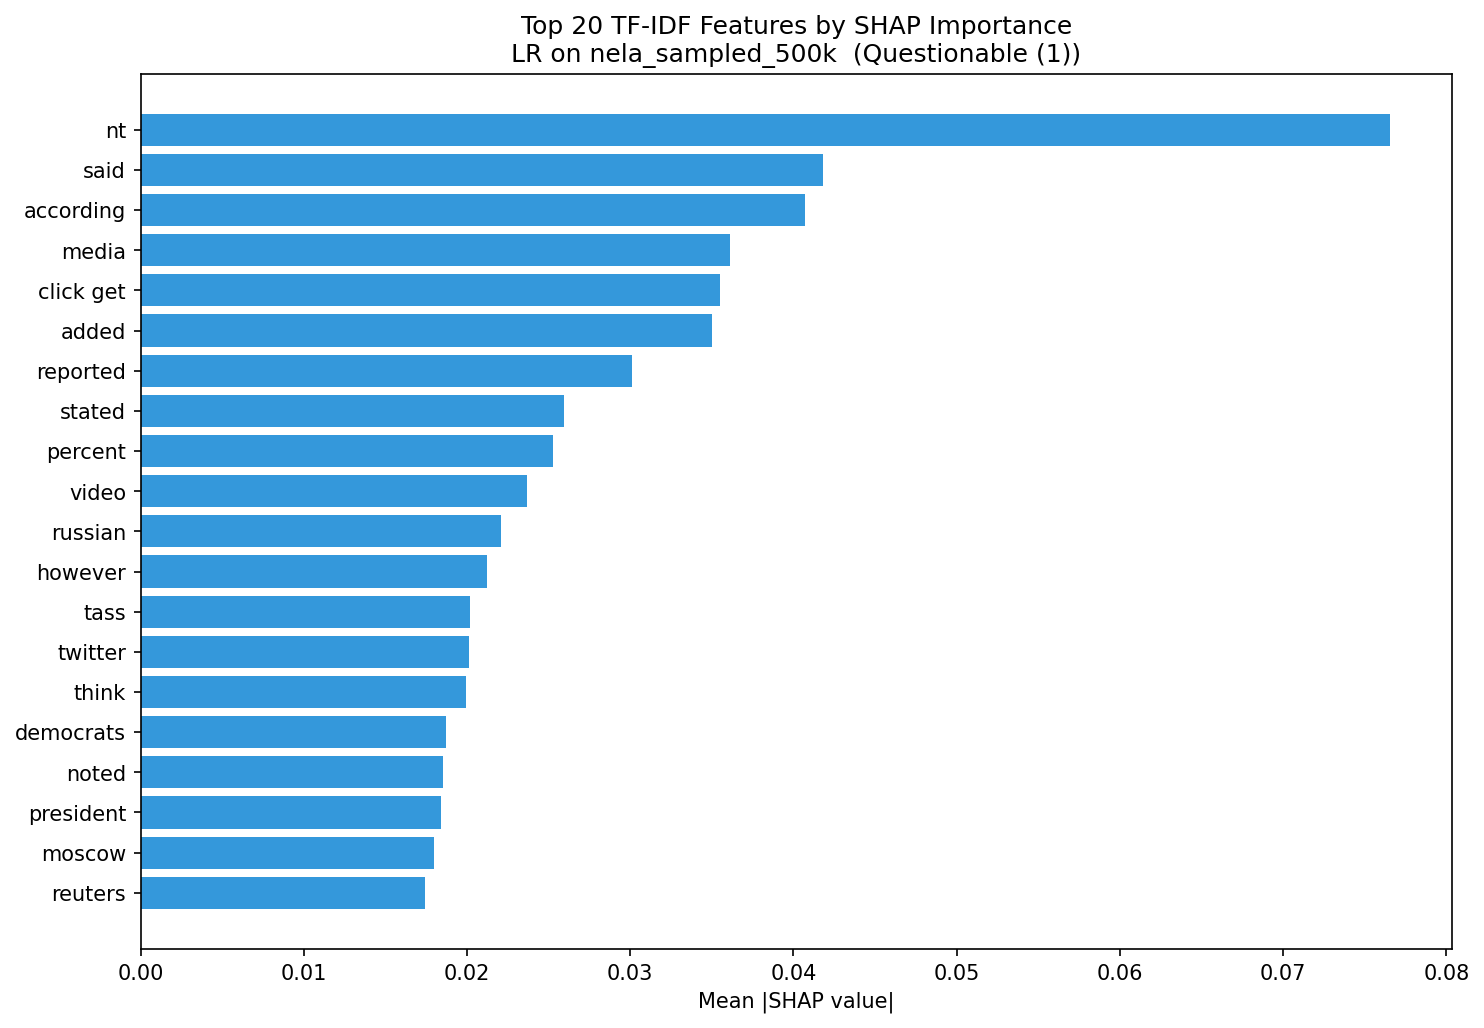

In [10]:
display(Image(os.path.join(shap_results, 'nela_sampled_500k_lr', 'global_importance_top20_cls1.png'), width=700))

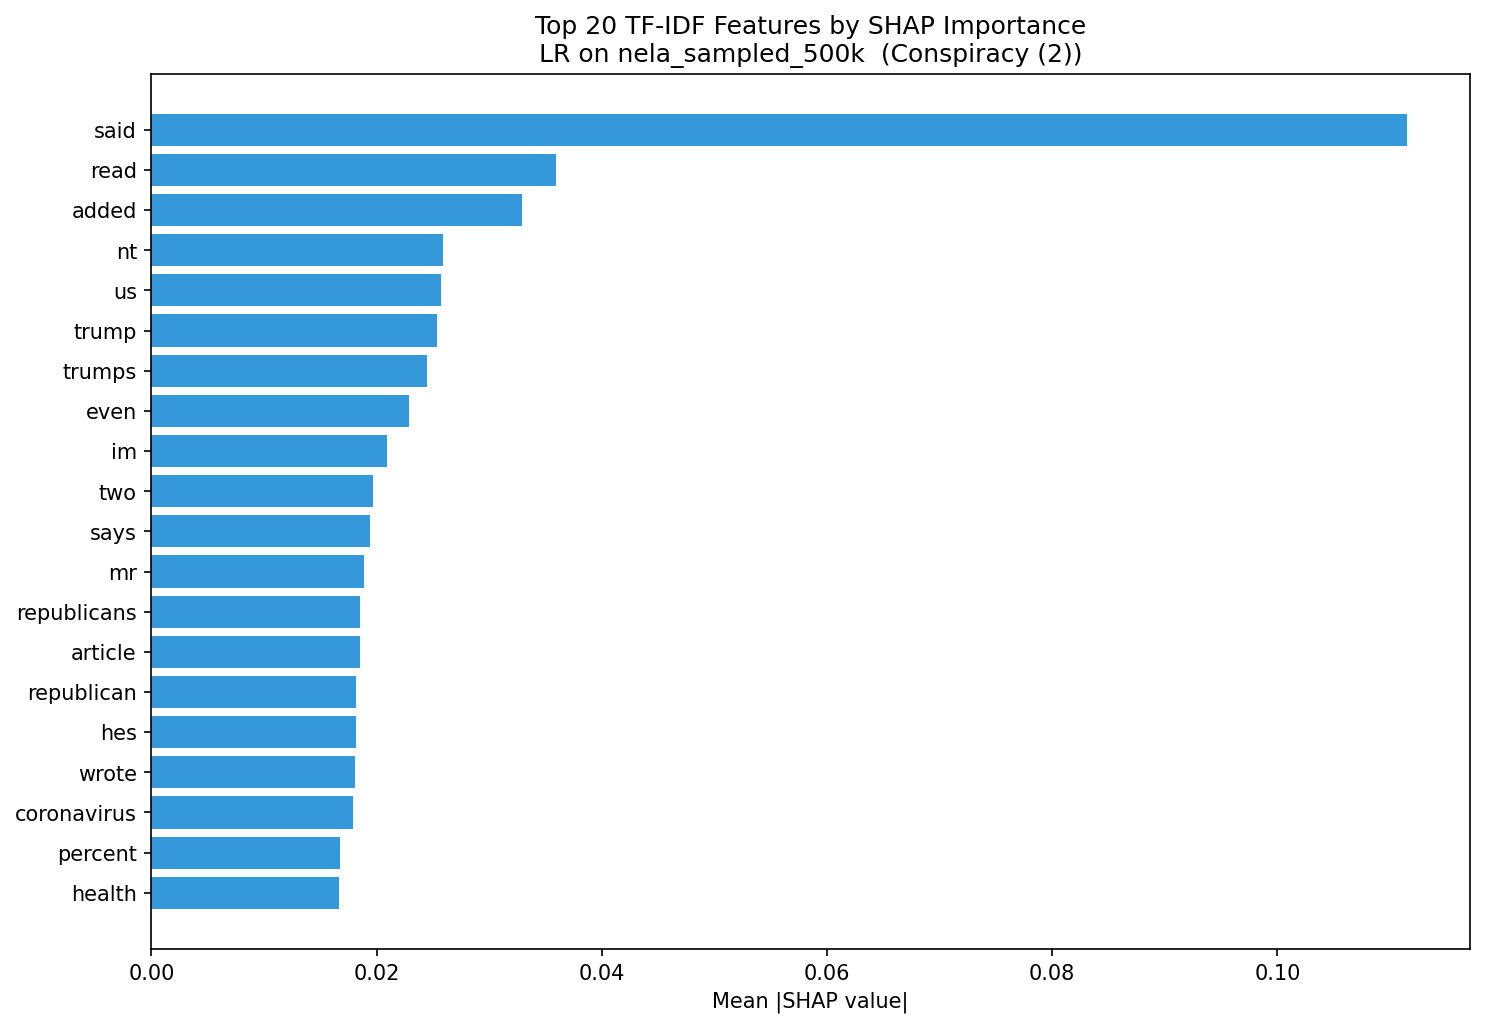

In [11]:
display(Image(os.path.join(shap_results, 'nela_sampled_500k_lr', 'global_importance_top20_cls2.png'), width=700))

**NELA SHAP finding:** The NELA-GT model produces interpretably different feature profiles per class. The Conspiracy and Questionable class highlights topic-specific vocabulary (health/medical misinformation terms, political conspiracy language). The Reliable class features show reliance towards professional journalism conventions. No single outlet source dominates the important features list, confirming that training across 457 sources eliminates the source-identity shortcut.

**Latency:**
- **LR (0.44ms)** is the fastest model. Suitable for any real-time use case.
- **TextCNN (0.76ms)** offers nearly identical accuracy to BiLSTM on ISOT/WELFake with 30× faster inference — the best overall efficiency trade-off.
- **BERT/RoBERTa (~7.5ms)** are much slower than TextCNN with marginal accuracy gains on binary datasets where all models are already above 0.99.
- **RF (45ms)** is the slowest by far — ensemble tree inference does not benefit from the sparse TF-IDF representation as efficiently as linear models.

---
## 6. Code

Project source code is uploaded in project as zip and also available in a public github repository here, https://github.com/rajat17-personal/news-classification


```
news-classification/
|--
|-- notebooks/          # Data analysis for each dataset
|-- results/
    |-- checkpoints/    # All best ckpts from experiments
    |-- shap/           # Shap plots
    |-- results.md      # All experiment results in a table format
|-- src/
    |-- classical/      # model, features, train and explainability files for classical variants
    |-- deep_learning/  # model, train files for DL variants
    |-- transformers_/  # model, train files for transformers variants
    |-- nela/           # NELA preprocessing, cross-eval
    |-- pheme/          # PHEMEplus loader
    |-- utils/          # Config, metrics, data loader, results aggregator     
```

---
## 7. Experiences

### What Worked Well

The decision to use cross-dataset and out of distributional evaluation set for was one of the most important decisions. As we observed during the experiment the models perform to near perfect accuracy for within-dataset results, but when we evaluate against an out of training set the source fingerprinting problem was revealed. 

Training on wider ranged source of articles (488 publishers from NELA-GT) improved generalization. This result proved that source diversity helps to eliminate the source fingerprinting problem encountered.

### Challenges

Memory management for NELA was a repeated challenge. The 4.2M articles exceeded available RAM, for this I had to process the files in chunks and subsample to 500K articles.

Models trained on WELFake produced very low F1 scores when evaluated on ISOT, this was an alarming finding. WELFake-trained models learn to predict one class for everything on ISOT because the datasets have incompatible label semantics.

Transformers were not evaluated on NELA. due to the compute constraints. This is the most significant gap left in the evaluation, transformer cross-dataset generalization on NELA could be an important data point.

### Improvements

Hyperparameter tuning was minimal. A systematic grid search would potentially improve RF and XGB on NELA.

Test remaining model variants and the complete NELA articles that were not tested due to compute constraints.

### Lessons Learned

High within-dataset accuracy is not always the evidence of a working fake news detector. It should be further examined to confirm what behavior the model has actually learned.

Dataset construction is the dominant factor here. Model architecture matters less than training data diversity. The gap between ISOT-trained LR (0.26 cross-eval) and NELA-trained LR (0.57 cross-eval) is  explained by training data source diversity.

LIAR and article-level fake news are different tasks. Conflating them in benchmarks may produces misleading conclusions.


### 7.5 Future Work

**Evaluate against AI-generated fake news.** Models trained on human-authored articles may not generalize to LLM-generated misinformation, which tends to be stylistically indistinguishable from professional journalism. Testing on datasets like RAID or HC3 would reveal this gap.

**Zero-shot LLM comparison.** Modern large language models (Claude, GPT-4) can be made to classify a text article/tweet about credibility via prompting without any task-specific training. Comparing their zero-shot macro-F1 against the best fine-tuned models in this study would calibrate how much of the remaining performance gap is addressable by scale alone.

**Multi-modal Inputs** Article text alone misses images, video, and social engagement signals that human fact-checkers routinely use. A system that jointly encodes headline, body text, article images, and sharing metadata would be substantially more robust.

---

## References

- Vosoughi, S., Roy, D., & Aral, S. (2018). The spread of true and false news online. *Science*, 359(6380), 1146–1151.
- Ahmed, H., Traore, I., & Saad, S. (2018). Detecting opinion spams and fake news using text classification. *Security and Privacy*, 1(1), e9. [ISOT dataset]
- Verma, P. K., Agrawal, P., Amorim, I., & Prodan, R. (2021). WELFake: Word embedding over linguistic features for fake news detection. *IEEE Transactions on Computational Social Systems*, 8(4), 881–893.
- Wang, W. Y. (2017). "Liar, Liar Pants on Fire": A new benchmark dataset for fake news detection. *ACL 2017*.
- Gruppi, M., Horne, B. D., & Adalı, S. (2022). NELA-GT-2022: A Large Multi-Labelled News Dataset for The Study of Misinformation in News Articles. *arXiv:2203.05659*.
- [An introduction to explainable AI with Shapley values](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html#)
